In [1]:
# ============================================================
# YOLO DATASET COMPLETE ANALYSIS - SINGLE CELL
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import yaml
import pandas as pd

# ------------------------------------------------------------
# 1. CHANGE ONLY THIS PATH
# ------------------------------------------------------------
DATASET_ROOT = Path(r"D:\MY Projects\Steel Defect Detection\data\GC10_DET_YOLO")

# Example:
# DATASET_ROOT = Path(r"D:\Datasets\GC10-DET")


# ------------------------------------------------------------
# 2. FIND data.yaml
# ------------------------------------------------------------
yaml_files = list(DATASET_ROOT.glob("*.yaml")) + list(DATASET_ROOT.glob("*.yml"))

if not yaml_files:
    raise FileNotFoundError("No data.yaml file found in DATASET_ROOT")

YAML_PATH = yaml_files[0]

with open(YAML_PATH, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

# Class names
names = data.get("names", {})

if isinstance(names, list):
    class_names = {i: str(name) for i, name in enumerate(names)}
else:
    class_names = {int(k): str(v) for k, v in names.items()}

NUM_CLASSES = len(class_names)


# ------------------------------------------------------------
# 3. FIND TRAIN / VAL / TEST DIRECTORIES
# ------------------------------------------------------------
def find_split(split):
    """
    Finds images and labels for train/val/test.
    Supports:
        dataset/images/train
        dataset/labels/train

    and YAML paths such as:
        train: images/train
    """

    image_candidates = [
        DATASET_ROOT / "images" / split,
        DATASET_ROOT / split / "images",
    ]

    label_candidates = [
        DATASET_ROOT / "labels" / split,
        DATASET_ROOT / split / "labels",
    ]

    image_dir = next((p for p in image_candidates if p.exists()), None)
    label_dir = next((p for p in label_candidates if p.exists()), None)

    if image_dir is None:
        return None, None

    return image_dir, label_dir


# ------------------------------------------------------------
# 4. IMAGE EXTENSIONS
# ------------------------------------------------------------
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}


# ------------------------------------------------------------
# 5. ANALYZE ONE SPLIT
# ------------------------------------------------------------
def analyze_split(split):

    image_dir, label_dir = find_split(split)

    if image_dir is None:
        return None

    images = [
        p for p in image_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    total_images = len(images)

    class_instances = Counter()
    class_images = Counter()

    instances_per_image = []
    classes_per_image = []

    images_with_multiple_classes = 0
    images_with_multiple_instances = 0

    missing_labels = 0
    empty_labels = 0
    invalid_labels = 0

    for image_path in images:

        # Corresponding label
        if label_dir is not None:
            label_path = label_dir / (image_path.stem + ".txt")
        else:
            label_path = None

        image_classes = []
        image_instance_count = 0

        if label_path is None or not label_path.exists():
            missing_labels += 1
            instances_per_image.append(0)
            classes_per_image.append(0)
            continue

        with open(label_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        if not lines:
            empty_labels += 1
            instances_per_image.append(0)
            classes_per_image.append(0)
            continue

        for line in lines:

            parts = line.split()

            # YOLO format:
            # class_id x_center y_center width height
            if len(parts) < 5:
                invalid_labels += 1
                continue

            try:
                class_id = int(float(parts[0]))

                if class_id not in class_names:
                    invalid_labels += 1
                    continue

                class_instances[class_id] += 1
                image_classes.append(class_id)
                image_instance_count += 1

            except ValueError:
                invalid_labels += 1

        unique_classes = set(image_classes)

        # Number of different classes in this image
        classes_per_image.append(len(unique_classes))

        # Number of total objects/instances in this image
        instances_per_image.append(image_instance_count)

        # Count image ONCE for every class present
        for class_id in unique_classes:
            class_images[class_id] += 1

        if len(unique_classes) > 1:
            images_with_multiple_classes += 1

        if image_instance_count > 1:
            images_with_multiple_instances += 1

    total_instances = sum(class_instances.values())

    return {
        "images": total_images,
        "instances": total_instances,
        "class_instances": class_instances,
        "class_images": class_images,
        "instances_per_image": instances_per_image,
        "classes_per_image": classes_per_image,
        "multi_class_images": images_with_multiple_classes,
        "multi_instance_images": images_with_multiple_instances,
        "missing_labels": missing_labels,
        "empty_labels": empty_labels,
        "invalid_labels": invalid_labels,
    }


# ------------------------------------------------------------
# 6. ANALYZE TRAIN / VAL / TEST
# ------------------------------------------------------------
results = {}

for split in ["train", "val", "test"]:
    result = analyze_split(split)

    if result is not None:
        results[split] = result


if not results:
    raise RuntimeError(
        "Could not find train/val/test image directories. "
        "Check DATASET_ROOT."
    )


# ------------------------------------------------------------
# 7. COMBINE ALL SPLITS
# ------------------------------------------------------------
combined = {
    "images": 0,
    "instances": 0,
    "class_instances": Counter(),
    "class_images": Counter(),
    "instances_per_image": [],
    "classes_per_image": [],
    "multi_class_images": 0,
    "multi_instance_images": 0,
    "missing_labels": 0,
    "empty_labels": 0,
    "invalid_labels": 0,
}

for split, r in results.items():

    combined["images"] += r["images"]
    combined["instances"] += r["instances"]

    combined["class_instances"].update(r["class_instances"])
    combined["class_images"].update(r["class_images"])

    combined["instances_per_image"].extend(
        r["instances_per_image"]
    )

    combined["classes_per_image"].extend(
        r["classes_per_image"]
    )

    combined["multi_class_images"] += r["multi_class_images"]
    combined["multi_instance_images"] += r["multi_instance_images"]

    combined["missing_labels"] += r["missing_labels"]
    combined["empty_labels"] += r["empty_labels"]
    combined["invalid_labels"] += r["invalid_labels"]


# ------------------------------------------------------------
# 8. PRINT GENERAL DATASET INFORMATION
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("              YOLO DATASET COMPLETE ANALYSIS")
print("=" * 70)

print(f"\nDataset path        : {DATASET_ROOT}")
print(f"YAML file           : {YAML_PATH.name}")
print(f"Number of classes   : {NUM_CLASSES}")

print("\nClass names:")
for cid, cname in class_names.items():
    print(f"  {cid}: {cname}")


# ------------------------------------------------------------
# 9. SPLIT SUMMARY
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("SPLIT SUMMARY")
print("-" * 70)

total_images = combined["images"]
total_instances = combined["instances"]

split_rows = []

for split, r in results.items():

    image_pct = (
        r["images"] / total_images * 100
        if total_images else 0
    )

    instance_pct = (
        r["instances"] / total_instances * 100
        if total_instances else 0
    )

    avg_inst = (
        r["instances"] / r["images"]
        if r["images"] else 0
    )

    split_rows.append({
        "Split": split.upper(),
        "Images": r["images"],
        "Image %": round(image_pct, 2),
        "Instances": r["instances"],
        "Instance %": round(instance_pct, 2),
        "Avg Instances/Image": round(avg_inst, 2)
    })

split_rows.append({
    "Split": "TOTAL",
    "Images": total_images,
    "Image %": 100.0,
    "Instances": total_instances,
    "Instance %": 100.0,
    "Avg Instances/Image": round(
        total_instances / total_images, 2
    ) if total_images else 0
})

print(pd.DataFrame(split_rows).to_string(index=False))


# ------------------------------------------------------------
# 10. CLASS DISTRIBUTION
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("OVERALL CLASS DISTRIBUTION")
print("-" * 70)

class_rows = []

for cid in sorted(class_names):

    inst = combined["class_instances"][cid]
    imgs = combined["class_images"][cid]

    inst_pct = (
        inst / total_instances * 100
        if total_instances else 0
    )

    image_pct = (
        imgs / total_images * 100
        if total_images else 0
    )

    class_rows.append({
        "Class ID": cid,
        "Class Name": class_names[cid],
        "Instances": inst,
        "Instance %": round(inst_pct, 2),
        "Images Containing Class": imgs,
        "Image %": round(image_pct, 2)
    })

class_df = pd.DataFrame(class_rows)

print(class_df.to_string(index=False))


# ------------------------------------------------------------
# 11. CLASS DISTRIBUTION FOR EACH SPLIT
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("CLASS DISTRIBUTION BY SPLIT")
print("-" * 70)

for split, r in results.items():

    print(f"\n[{split.upper()}]")

    rows = []

    for cid in sorted(class_names):

        inst = r["class_instances"][cid]
        imgs = r["class_images"][cid]

        rows.append({
            "Class ID": cid,
            "Class": class_names[cid],
            "Instances": inst,
            "Images": imgs
        })

    print(pd.DataFrame(rows).to_string(index=False))


# ------------------------------------------------------------
# 12. IMAGE / INSTANCE STATISTICS
# ------------------------------------------------------------
inst_list = combined["instances_per_image"]
class_list = combined["classes_per_image"]

print("\n" + "-" * 70)
print("IMAGE / INSTANCE STATISTICS")
print("-" * 70)

print(f"Total images                  : {total_images}")
print(f"Total instances               : {total_instances}")

if inst_list:

    print(
        f"Average instances/image      : "
        f"{total_instances / total_images:.2f}"
    )

    print(
        f"Minimum instances/image      : "
        f"{min(inst_list)}"
    )

    print(
        f"Maximum instances/image      : "
        f"{max(inst_list)}"
    )

    print(
        f"Median instances/image       : "
        f"{pd.Series(inst_list).median():.2f}"
    )

print(
    f"Images with >1 instance       : "
    f"{combined['multi_instance_images']}"
)

print(
    f"Images with >1 class          : "
    f"{combined['multi_class_images']}"
)


# ------------------------------------------------------------
# 13. HOW MANY CLASSES PER IMAGE?
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("NUMBER OF DIFFERENT CLASSES PER IMAGE")
print("-" * 70)

class_count_distribution = Counter(class_list)

for n_classes in sorted(class_count_distribution):

    count = class_count_distribution[n_classes]

    print(
        f"{n_classes} class(es) : "
        f"{count} images "
        f"({count / total_images * 100:.2f}%)"
    )


# ------------------------------------------------------------
# 14. DATASET INTEGRITY CHECK
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("DATASET INTEGRITY CHECK")
print("-" * 70)

print(f"Images without label file : {combined['missing_labels']}")
print(f"Empty label files         : {combined['empty_labels']}")
print(f"Invalid annotations       : {combined['invalid_labels']}")

if (
    combined["missing_labels"] == 0
    and combined["empty_labels"] == 0
    and combined["invalid_labels"] == 0
):
    print("\n✓ Dataset annotation structure looks valid.")
else:
    print("\n⚠ WARNING: Check the annotation problems above.")


# ------------------------------------------------------------
# 15. FINAL RESEARCH SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("RESEARCH-READY DATASET SUMMARY")
print("=" * 70)

print(f"""
Total Images              : {total_images}
Total Object Instances    : {total_instances}
Total Classes             : {NUM_CLASSES}

Train Images              : {results.get('train', {}).get('images', 0)}
Validation Images         : {results.get('val', {}).get('images', 0)}
Test Images               : {results.get('test', {}).get('images', 0)}

Average Objects/Image     : {
    round(total_instances / total_images, 2)
    if total_images else 0
}

Images with Multiple
Object Instances          : {combined['multi_instance_images']}

Images with Multiple
Classes                   : {combined['multi_class_images']}
""")

print("=" * 70)
print("Analysis completed.")
print("=" * 70)


              YOLO DATASET COMPLETE ANALYSIS

Dataset path        : D:\MY Projects\Steel Defect Detection\data\GC10_DET_YOLO
YAML file           : data.yaml
Number of classes   : 10

Class names:
  0: Punching Hole
  1: Welding Line
  2: Crescent Gap
  3: Water Spot
  4: Oil Spot
  5: Silk Spot
  6: Inclusion
  7: Rolled Pit
  8: Crease
  9: Waist Folding

----------------------------------------------------------------------
SPLIT SUMMARY
----------------------------------------------------------------------
Split  Images  Image %  Instances  Instance %  Avg Instances/Image
TRAIN    1817    79.69       2807       79.25                 1.54
  VAL     224     9.82        342        9.66                 1.53
 TEST     239    10.48        393       11.10                 1.64
TOTAL    2280   100.00       3542      100.00                 1.55

----------------------------------------------------------------------
OVERALL CLASS DISTRIBUTION
--------------------------------------------------


              YOLO DATASET VISUAL ANALYSIS

Dataset : D:\MY Projects\Steel Defect Detection\data\GC10_DET_YOLO
Classes : 10
Images  : 2280
Objects : 3542
Average objects/image : 1.55

---------------------------------------------------------------------------
SPLIT INFORMATION
---------------------------------------------------------------------------
Split  Images  Instances  Image_Percentage  Instance_Percentage
TRAIN    1817       2807             79.69                79.25
  VAL     224        342              9.82                 9.66
 TEST     239        393             10.48                11.10

---------------------------------------------------------------------------
CLASS DISTRIBUTION
---------------------------------------------------------------------------
 Class_ID         Class  Instances  Images  train_Instances  train_Images  val_Instances  val_Images  test_Instances  test_Images
        0 Punching Hole        324     324              262           262             2

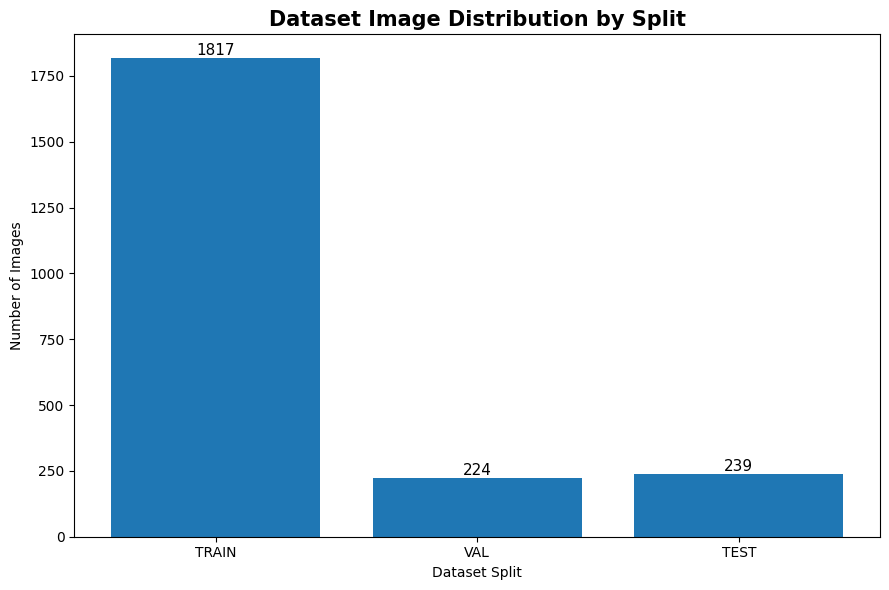

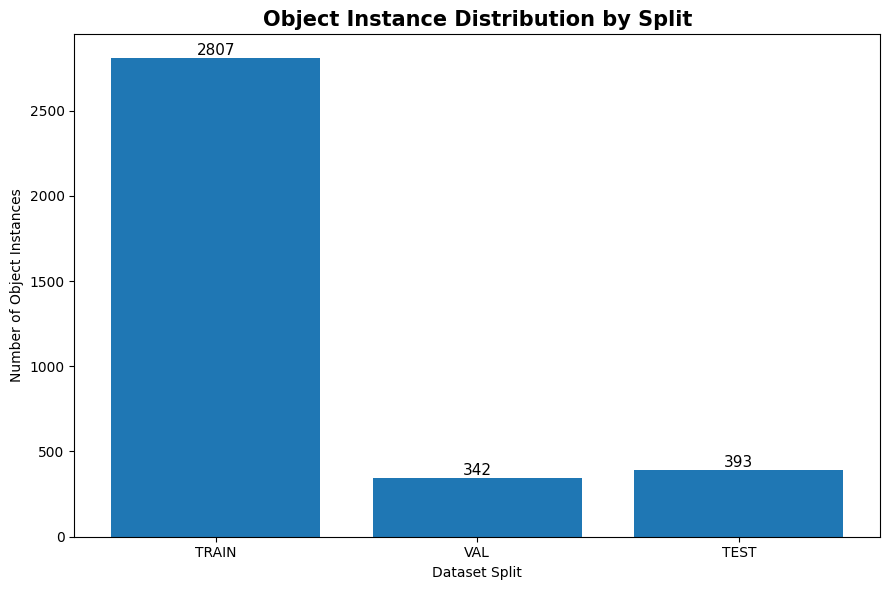

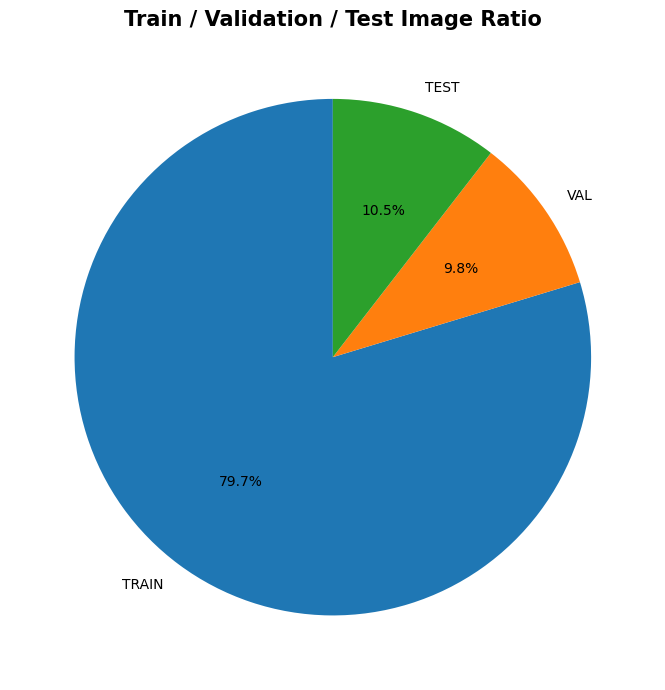

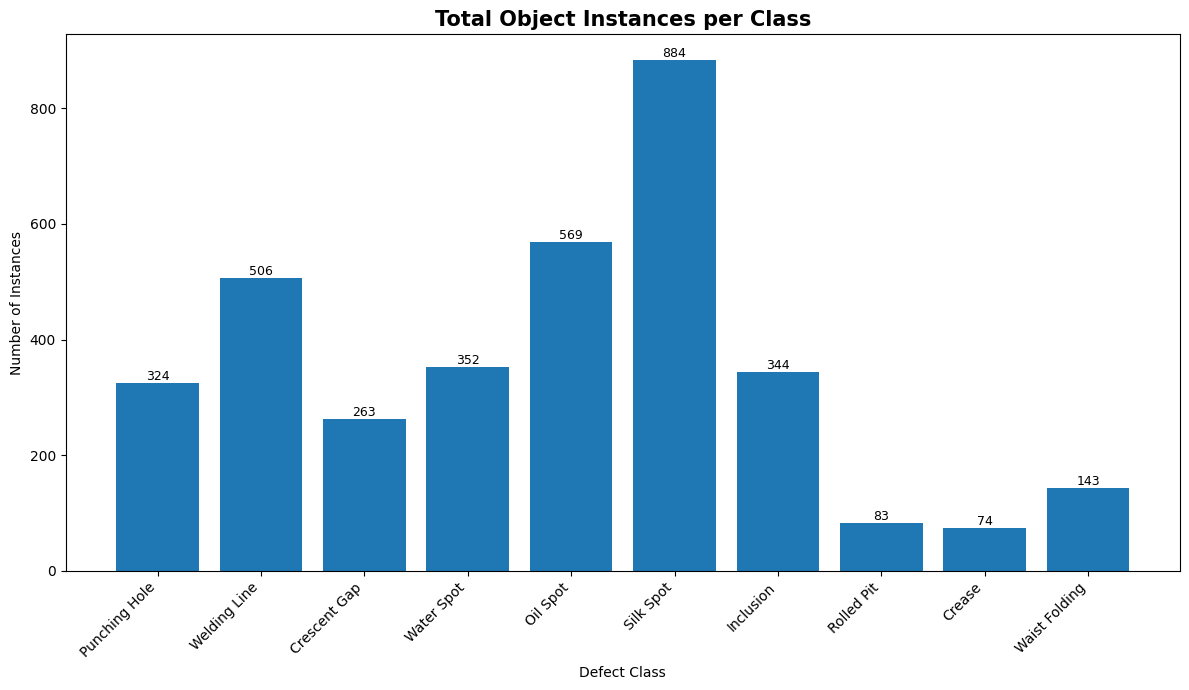

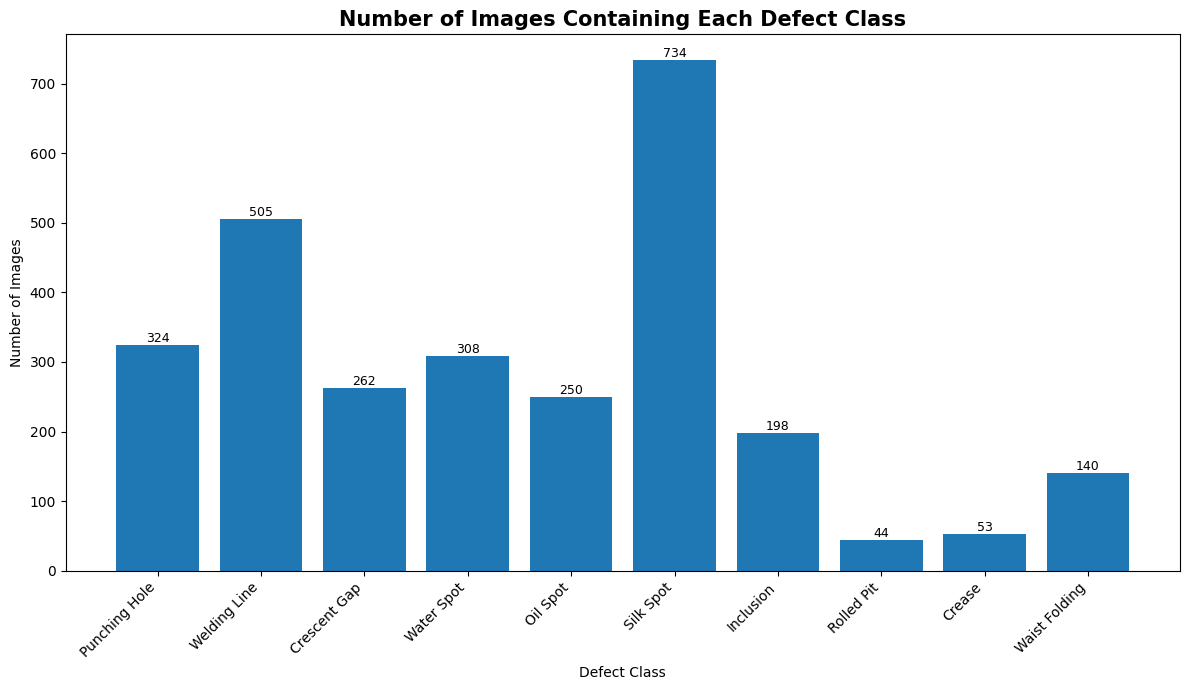

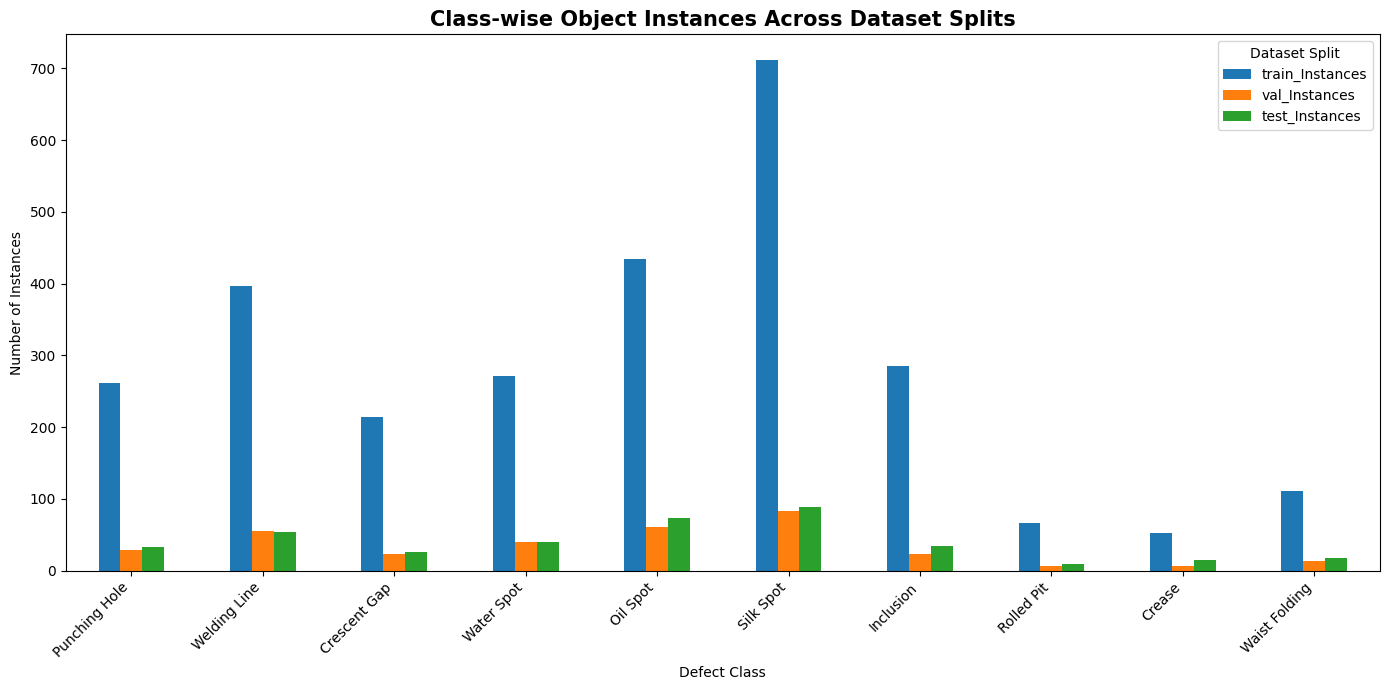

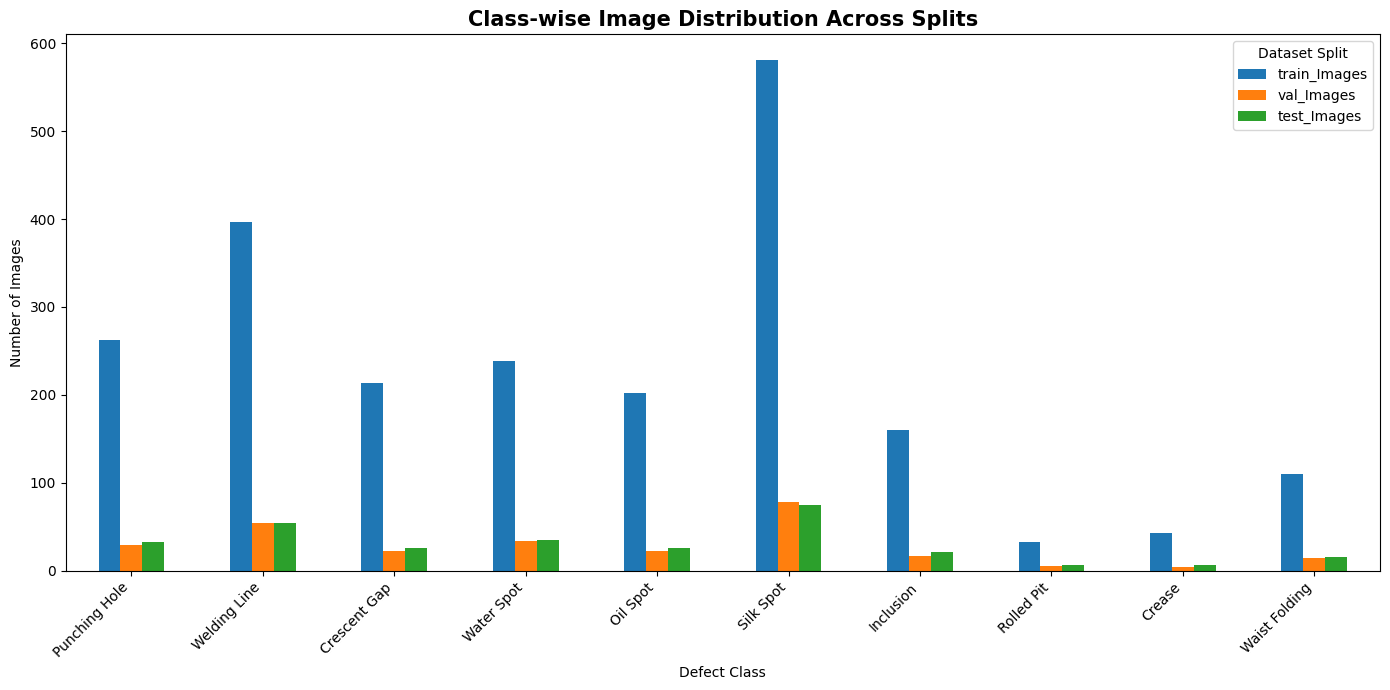

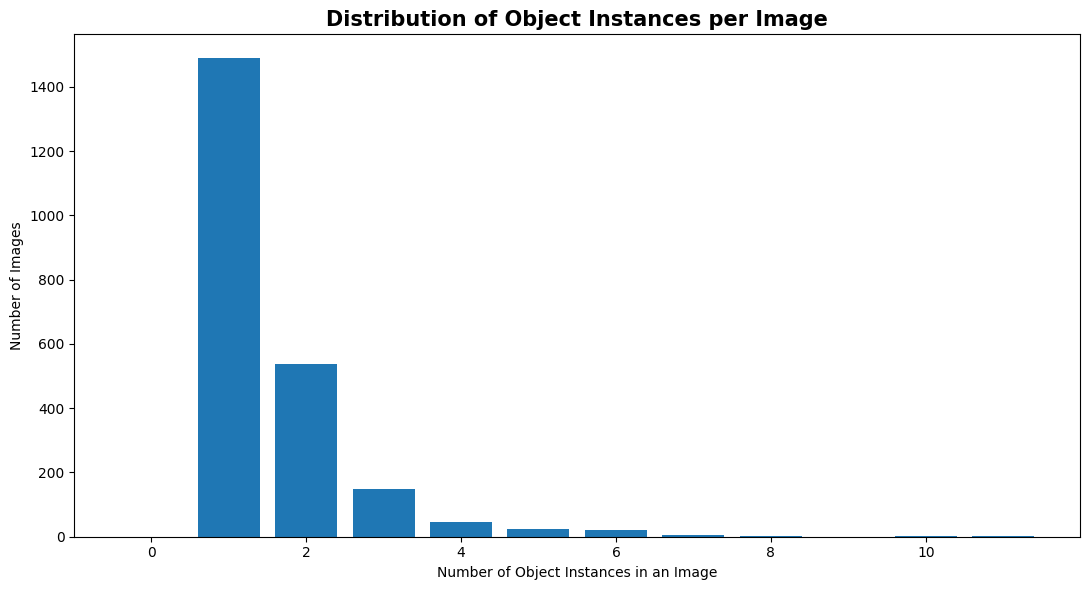

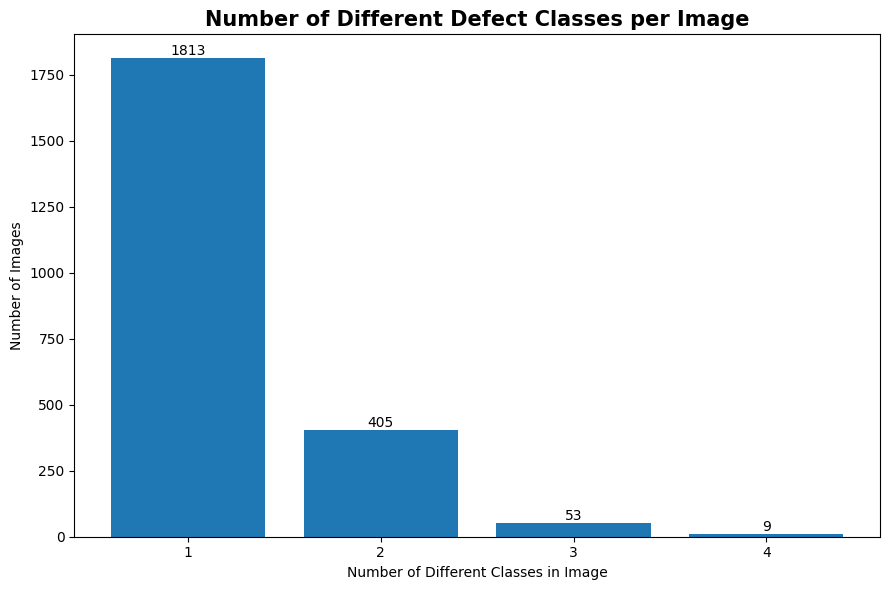

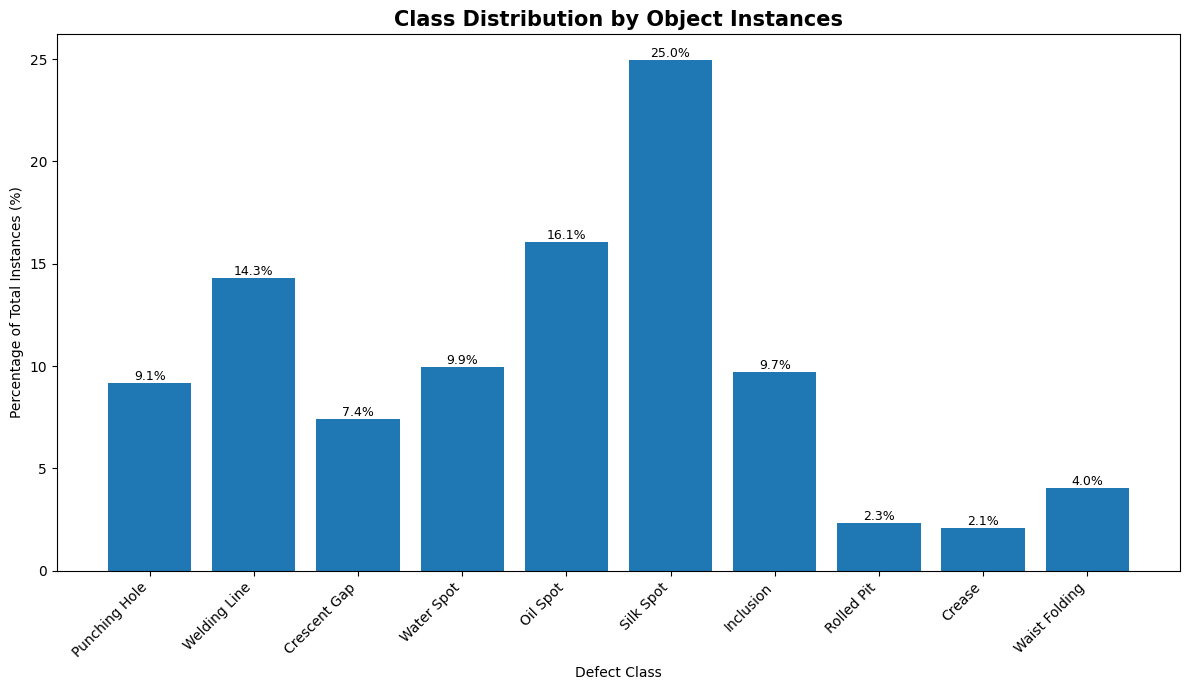

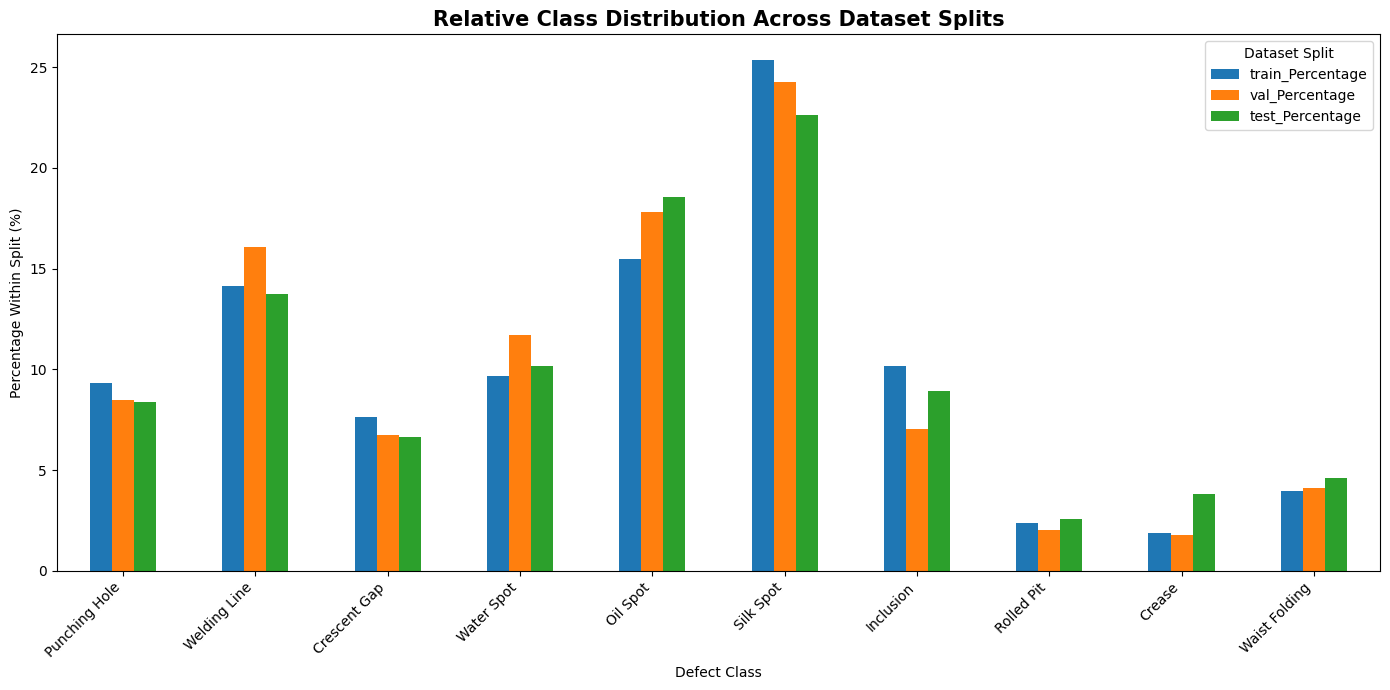

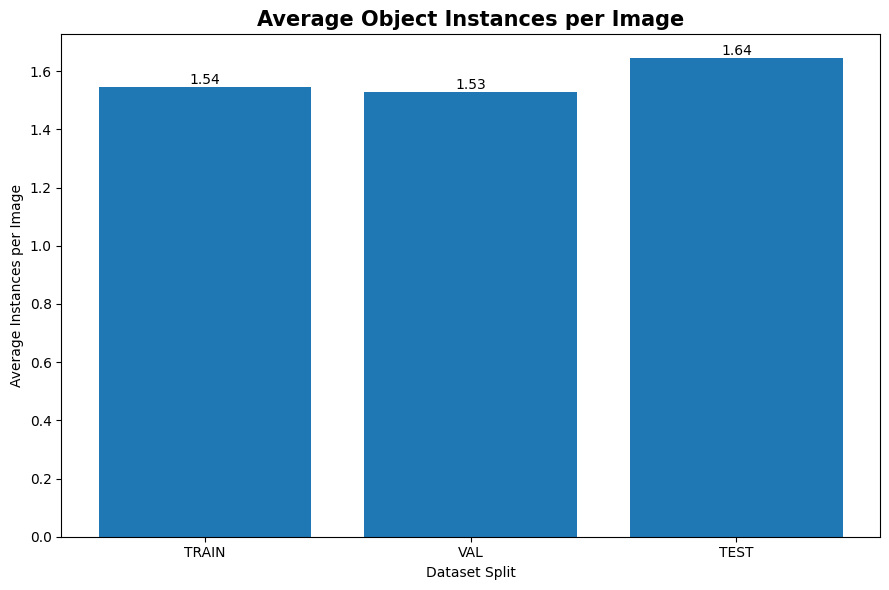

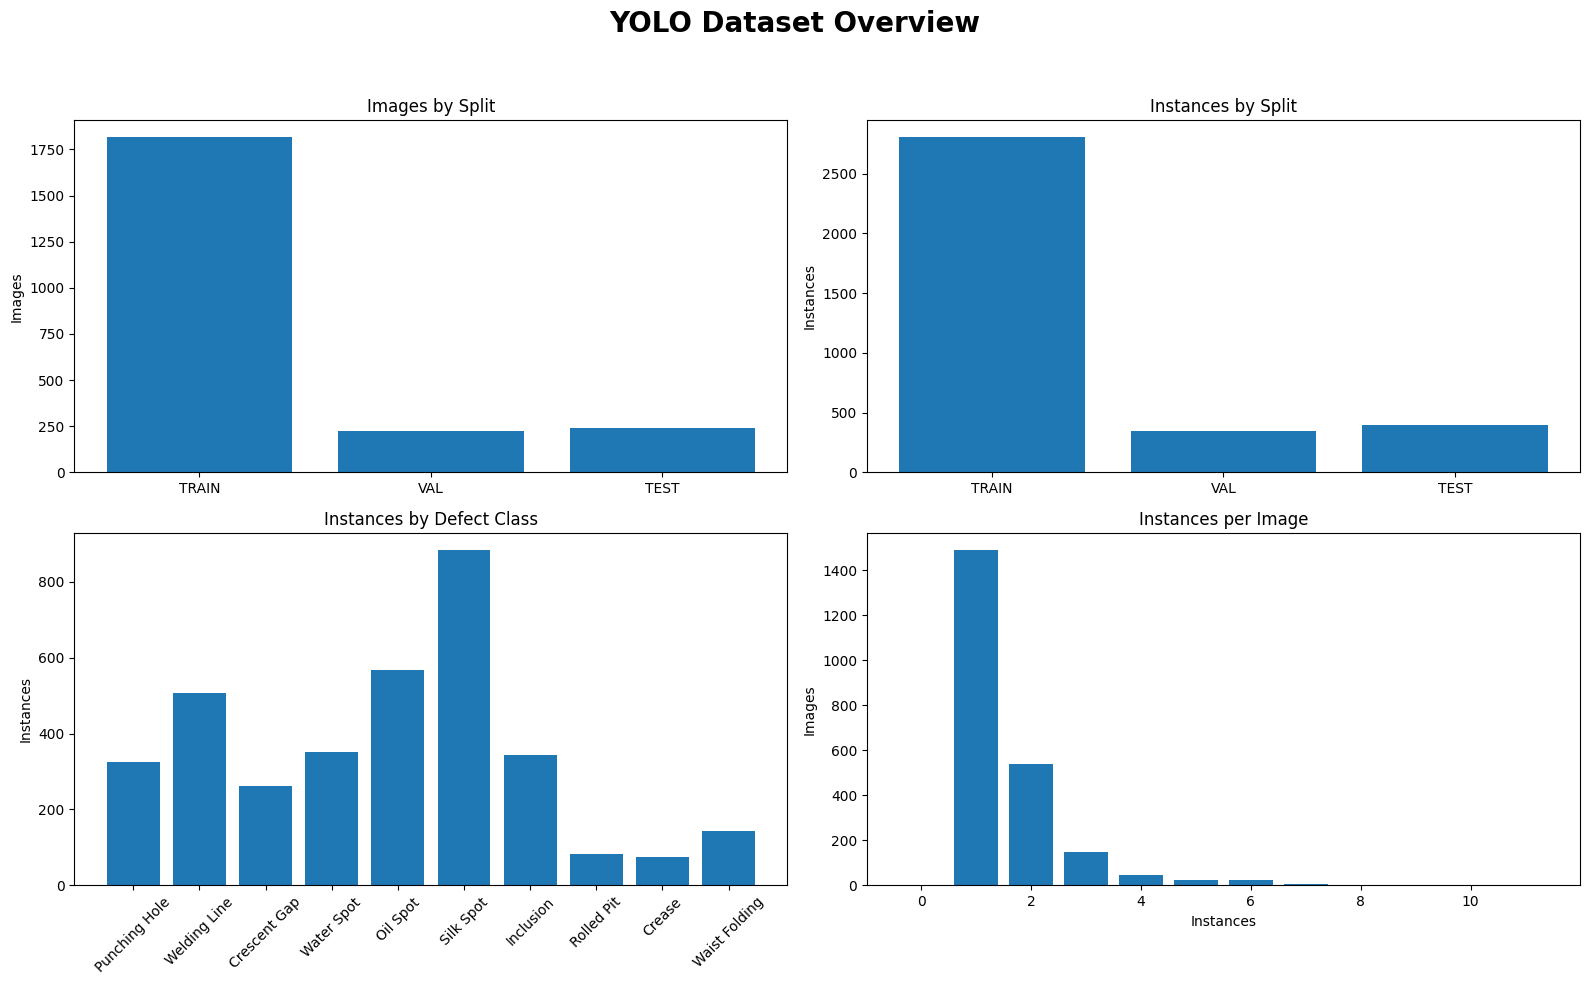


AUTOMATIC DATASET INTERPRETATION
Total images              : 2280
Total object instances    : 3542
Number of classes         : 10
Average objects/image     : 1.55
Most represented class    : Silk Spot
Instances                 : 884
Least represented class   : Crease
Instances                 : 74
Maximum/Minimum ratio     : 11.95:1

Interpretation:
• The class-instance distribution can be used to assess class imbalance.
• The train/validation/test charts can be used to verify the 8:1:1 partition.
• The instances-per-image histogram shows whether images contain mostly single or multiple defects.
• The class-wise split charts show whether class representation is consistent across train, validation, and test sets.
Visualization completed successfully.


In [8]:
# ================================================================
# YOLO DATASET VISUALIZATION & ANALYSIS
# Single-cell Jupyter / Google Colab script
# ================================================================

from pathlib import Path
from collections import Counter
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# 1. CHANGE ONLY THIS PATH
# ================================================================

DATASET_ROOT = Path(r"D:\MY Projects\Steel Defect Detection\data\GC10_DET_YOLO")

# Example:
# DATASET_ROOT = Path(r"D:\Datasets\GC10-DET")


# ================================================================
# 2. FIND data.yaml
# ================================================================

yaml_files = (
    list(DATASET_ROOT.glob("*.yaml")) +
    list(DATASET_ROOT.glob("*.yml"))
)

if not yaml_files:
    raise FileNotFoundError(
        "No data.yaml / data.yml found in DATASET_ROOT."
    )

YAML_PATH = yaml_files[0]

with open(YAML_PATH, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)


# ================================================================
# 3. READ CLASS NAMES
# ================================================================

names = data.get("names", {})

if isinstance(names, list):
    CLASS_NAMES = {
        i: str(name)
        for i, name in enumerate(names)
    }
else:
    CLASS_NAMES = {
        int(k): str(v)
        for k, v in names.items()
    }

NUM_CLASSES = len(CLASS_NAMES)


# ================================================================
# 4. FIND DATASET DIRECTORIES
# ================================================================

def find_split(split):

    image_candidates = [
        DATASET_ROOT / "images" / split,
        DATASET_ROOT / split / "images"
    ]

    label_candidates = [
        DATASET_ROOT / "labels" / split,
        DATASET_ROOT / split / "labels"
    ]

    image_dir = next(
        (p for p in image_candidates if p.exists()),
        None
    )

    label_dir = next(
        (p for p in label_candidates if p.exists()),
        None
    )

    return image_dir, label_dir


IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}


# ================================================================
# 5. ANALYZE EACH SPLIT
# ================================================================

def analyze_split(split):

    image_dir, label_dir = find_split(split)

    if image_dir is None:
        return None

    images = [
        p for p in image_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_instances = Counter()
    class_images = Counter()

    instances_per_image = []
    classes_per_image = []

    for image_path in images:

        if label_dir is None:
            continue

        label_path = label_dir / (image_path.stem + ".txt")

        image_classes = []
        instance_count = 0

        if label_path.exists():

            with open(
                label_path,
                "r",
                encoding="utf-8"
            ) as f:

                lines = [
                    line.strip()
                    for line in f
                    if line.strip()
                ]

            for line in lines:

                parts = line.split()

                if len(parts) < 5:
                    continue

                try:
                    class_id = int(float(parts[0]))

                    if class_id not in CLASS_NAMES:
                        continue

                    class_instances[class_id] += 1

                    image_classes.append(class_id)

                    instance_count += 1

                except:
                    continue

        instances_per_image.append(
            instance_count
        )

        unique_classes = set(image_classes)

        classes_per_image.append(
            len(unique_classes)
        )

        for class_id in unique_classes:
            class_images[class_id] += 1

    return {
        "images": len(images),
        "instances": sum(class_instances.values()),
        "class_instances": class_instances,
        "class_images": class_images,
        "instances_per_image": instances_per_image,
        "classes_per_image": classes_per_image
    }


# ================================================================
# 6. RUN ANALYSIS
# ================================================================

results = {}

for split in ["train", "val", "test"]:

    result = analyze_split(split)

    if result is not None:
        results[split] = result


if not results:
    raise RuntimeError(
        "No train/val/test directories found."
    )


# ================================================================
# 7. COMBINE DATA
# ================================================================

total_images = sum(
    r["images"]
    for r in results.values()
)

total_instances = sum(
    r["instances"]
    for r in results.values()
)


# ================================================================
# 8. DATAFRAME: SPLIT INFORMATION
# ================================================================

split_rows = []

for split, r in results.items():

    split_rows.append({
        "Split": split.upper(),
        "Images": r["images"],
        "Instances": r["instances"],
        "Image_Percentage":
            r["images"] / total_images * 100,
        "Instance_Percentage":
            r["instances"] / total_instances * 100
    })

split_df = pd.DataFrame(split_rows)


# ================================================================
# 9. DATAFRAME: CLASS INFORMATION
# ================================================================

class_rows = []

for cid in sorted(CLASS_NAMES):

    total_class_instances = sum(
        r["class_instances"][cid]
        for r in results.values()
    )

    total_class_images = sum(
        r["class_images"][cid]
        for r in results.values()
    )

    row = {
        "Class_ID": cid,
        "Class": CLASS_NAMES[cid],
        "Instances": total_class_instances,
        "Images": total_class_images
    }

    for split, r in results.items():

        row[f"{split}_Instances"] = \
            r["class_instances"][cid]

        row[f"{split}_Images"] = \
            r["class_images"][cid]

    class_rows.append(row)

class_df = pd.DataFrame(class_rows)


# ================================================================
# 10. PRINT SUMMARY
# ================================================================

print("\n" + "=" * 75)
print("              YOLO DATASET VISUAL ANALYSIS")
print("=" * 75)

print(f"\nDataset : {DATASET_ROOT}")
print(f"Classes : {NUM_CLASSES}")
print(f"Images  : {total_images}")
print(f"Objects : {total_instances}")

print(
    f"Average objects/image : "
    f"{total_instances / total_images:.2f}"
)


print("\n" + "-" * 75)
print("SPLIT INFORMATION")
print("-" * 75)

print(
    split_df.round(2).to_string(index=False)
)


print("\n" + "-" * 75)
print("CLASS DISTRIBUTION")
print("-" * 75)

print(
    class_df.round(2).to_string(index=False)
)


# ================================================================
# 11. CHART 1
# TRAIN / VAL / TEST IMAGE DISTRIBUTION
# ================================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    split_df["Split"],
    split_df["Images"]
)

plt.title(
    "Dataset Image Distribution by Split",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

for bar, value in zip(
    bars,
    split_df["Images"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()


# ================================================================
# 12. CHART 2
# TRAIN / VAL / TEST INSTANCE DISTRIBUTION
# ================================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    split_df["Split"],
    split_df["Instances"]
)

plt.title(
    "Object Instance Distribution by Split",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Object Instances")

for bar, value in zip(
    bars,
    split_df["Instances"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()


# ================================================================
# 13. CHART 3
# TRAIN / VAL / TEST PERCENTAGE
# ================================================================

plt.figure(figsize=(7, 7))

plt.pie(
    split_df["Images"],
    labels=split_df["Split"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Train / Validation / Test Image Ratio",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ================================================================
# 14. CHART 4
# TOTAL INSTANCES PER CLASS
# ================================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    class_df["Class"],
    class_df["Instances"]
)

plt.title(
    "Total Object Instances per Class",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Instances")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    class_df["Instances"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 15. CHART 5
# IMAGES CONTAINING EACH CLASS
# ================================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    class_df["Class"],
    class_df["Images"]
)

plt.title(
    "Number of Images Containing Each Defect Class",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    class_df["Images"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 16. CHART 6
# CLASS INSTANCES ACROSS TRAIN / VAL / TEST
# ================================================================

plot_df = class_df[
    ["Class"] +
    [
        f"{split}_Instances"
        for split in results
    ]
]

plot_df = plot_df.set_index("Class")

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Class-wise Object Instances Across Dataset Splits",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Instances")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Dataset Split"
)

plt.tight_layout()
plt.show()


# ================================================================
# 17. CHART 7
# CLASS IMAGES ACROSS TRAIN / VAL / TEST
# ================================================================

plot_df = class_df[
    ["Class"] +
    [
        f"{split}_Images"
        for split in results
    ]
]

plot_df = plot_df.set_index("Class")

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Class-wise Image Distribution Across Splits",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Dataset Split"
)

plt.tight_layout()
plt.show()


# ================================================================
# 18. CHART 8
# INSTANCE DISTRIBUTION PER IMAGE
# ================================================================

all_instances_per_image = []

for r in results.values():

    all_instances_per_image.extend(
        r["instances_per_image"]
    )

plt.figure(figsize=(11, 6))

plt.hist(
    all_instances_per_image,
    bins=range(
        0,
        max(all_instances_per_image) + 2
    ),
    align="left",
    rwidth=0.8
)

plt.title(
    "Distribution of Object Instances per Image",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Number of Object Instances in an Image"
)

plt.ylabel(
    "Number of Images"
)

plt.tight_layout()
plt.show()


# ================================================================
# 19. CHART 9
# NUMBER OF CLASSES PER IMAGE
# ================================================================

all_classes_per_image = []

for r in results.values():

    all_classes_per_image.extend(
        r["classes_per_image"]
    )

class_count = Counter(
    all_classes_per_image
)

x = sorted(class_count)
y = [
    class_count[i]
    for i in x
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    [str(i) for i in x],
    y
)

plt.title(
    "Number of Different Defect Classes per Image",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Number of Different Classes in Image"
)

plt.ylabel(
    "Number of Images"
)

for bar, value in zip(bars, y):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 20. CHART 10
# CLASS IMBALANCE
# ================================================================

class_df["Instance_Percentage"] = (
    class_df["Instances"]
    / total_instances
    * 100
)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    class_df["Class"],
    class_df["Instance_Percentage"]
)

plt.title(
    "Class Distribution by Object Instances",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Percentage of Total Instances (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    class_df["Instance_Percentage"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 21. CHART 11
# TRAIN / VAL / TEST CLASS BALANCE
# ================================================================

percentage_df = class_df[
    ["Class"] +
    [
        f"{split}_Instances"
        for split in results
    ]
].copy()

for split in results:

    percentage_df[
        f"{split}_Percentage"
    ] = (
        percentage_df[
            f"{split}_Instances"
        ]
        / results[split]["instances"]
        * 100
    )

percentage_plot = percentage_df[
    ["Class"] +
    [
        f"{split}_Percentage"
        for split in results
    ]
]

percentage_plot = percentage_plot.set_index(
    "Class"
)

percentage_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Relative Class Distribution Across Dataset Splits",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Percentage Within Split (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Dataset Split"
)

plt.tight_layout()
plt.show()


# ================================================================
# 22. CHART 12
# AVERAGE INSTANCES PER IMAGE BY SPLIT
# ================================================================

average_instances = []

for split, r in results.items():

    avg = (
        r["instances"] / r["images"]
        if r["images"] else 0
    )

    average_instances.append({
        "Split": split.upper(),
        "Average": avg
    })

average_df = pd.DataFrame(
    average_instances
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    average_df["Split"],
    average_df["Average"]
)

plt.title(
    "Average Object Instances per Image",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dataset Split")
plt.ylabel("Average Instances per Image")

for bar, value in zip(
    bars,
    average_df["Average"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 23. FINAL DATASET DASHBOARD
# ================================================================

fig = plt.figure(
    figsize=(16, 10)
)

fig.suptitle(
    "YOLO Dataset Overview",
    fontsize=20,
    fontweight="bold"
)

# ------------------------------------------------
# Dashboard 1: images
# ------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

ax1.bar(
    split_df["Split"],
    split_df["Images"]
)

ax1.set_title(
    "Images by Split"
)

ax1.set_ylabel(
    "Images"
)


# ------------------------------------------------
# Dashboard 2: instances
# ------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

ax2.bar(
    split_df["Split"],
    split_df["Instances"]
)

ax2.set_title(
    "Instances by Split"
)

ax2.set_ylabel(
    "Instances"
)


# ------------------------------------------------
# Dashboard 3: class distribution
# ------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

ax3.bar(
    class_df["Class"],
    class_df["Instances"]
)

ax3.set_title(
    "Instances by Defect Class"
)

ax3.set_ylabel(
    "Instances"
)

ax3.tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------
# Dashboard 4: instance/image
# ------------------------------------------------

ax4 = plt.subplot(2, 2, 4)

ax4.hist(
    all_instances_per_image,
    bins=range(
        0,
        max(all_instances_per_image) + 2
    ),
    align="left",
    rwidth=0.8
)

ax4.set_title(
    "Instances per Image"
)

ax4.set_xlabel(
    "Instances"
)

ax4.set_ylabel(
    "Images"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


# ================================================================
# 24. FINAL AUTOMATIC INTERPRETATION
# ================================================================

max_class = class_df.loc[
    class_df["Instances"].idxmax()
]

min_class = class_df.loc[
    class_df["Instances"].idxmin()
]

# Calculate average instances per image
average_instances_total = (
    total_instances / total_images
    if total_images > 0
    else 0
)

# Calculate imbalance ratio
if min_class["Instances"] > 0:
    imbalance_ratio = (
        max_class["Instances"]
        / min_class["Instances"]
    )
else:
    imbalance_ratio = float("inf")


print("\n" + "=" * 75)
print("AUTOMATIC DATASET INTERPRETATION")
print("=" * 75)

print(f"Total images              : {total_images}")
print(f"Total object instances    : {total_instances}")
print(f"Number of classes         : {NUM_CLASSES}")

print(
    f"Average objects/image     : "
    f"{average_instances_total:.2f}"
)

print(
    f"Most represented class    : "
    f"{max_class['Class']}"
)

print(
    f"Instances                 : "
    f"{int(max_class['Instances'])}"
)

print(
    f"Least represented class   : "
    f"{min_class['Class']}"
)

print(
    f"Instances                 : "
    f"{int(min_class['Instances'])}"
)

if imbalance_ratio != float("inf"):

    print(
        f"Maximum/Minimum ratio     : "
        f"{imbalance_ratio:.2f}:1"
    )

else:

    print(
        "Maximum/Minimum ratio     : Undefined "
        "(minimum class has zero instances)"
    )

print("\nInterpretation:")
print(
    "• The class-instance distribution can be used "
    "to assess class imbalance."
)

print(
    "• The train/validation/test charts can be used "
    "to verify the 8:1:1 partition."
)

print(
    "• The instances-per-image histogram shows whether "
    "images contain mostly single or multiple defects."
)

print(
    "• The class-wise split charts show whether class "
    "representation is consistent across train, validation, "
    "and test sets."
)

print("=" * 75)
print("Visualization completed successfully.")
print("=" * 75)


              YOLO DATASET VISUAL ANALYSIS

Dataset : D:\MY Projects\Steel Defect Detection\data\processed_v2
Classes : 6
Images  : 1800
Objects : 4189
Average objects/image : 2.33

---------------------------------------------------------------------------
SPLIT INFORMATION
---------------------------------------------------------------------------
Split  Images  Instances  Image_Percentage  Instance_Percentage
TRAIN    1260       2919              70.0                69.68
  VAL     360        828              20.0                19.77
 TEST     180        442              10.0                10.55

---------------------------------------------------------------------------
CLASS DISTRIBUTION
---------------------------------------------------------------------------
 Class_ID           Class  Instances  Images  train_Instances  train_Images  val_Instances  val_Images  test_Instances  test_Images
        0         crazing        689     300              470           204            

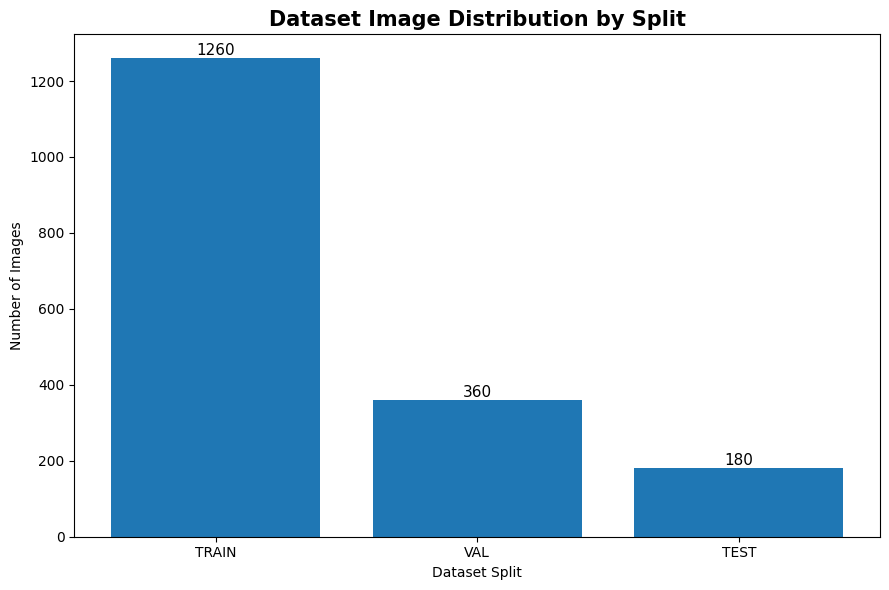

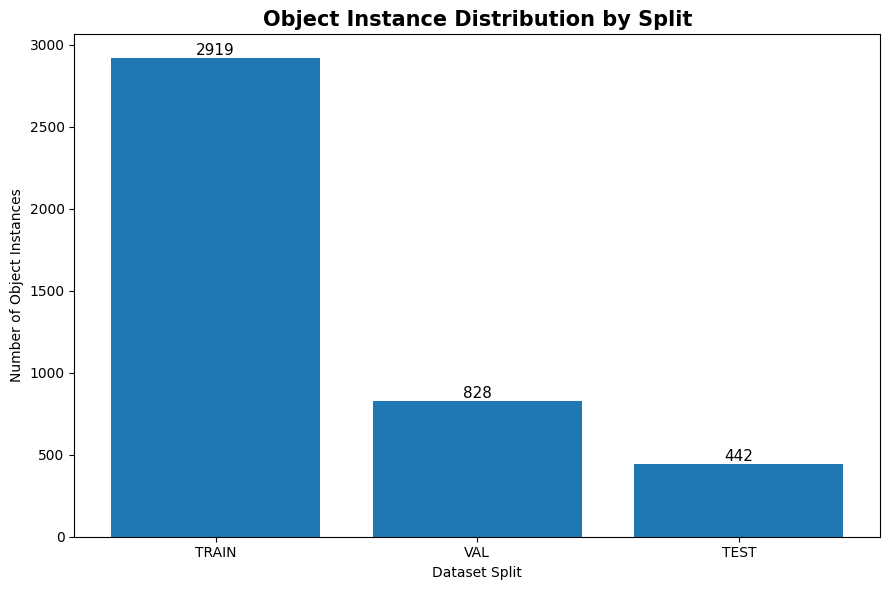

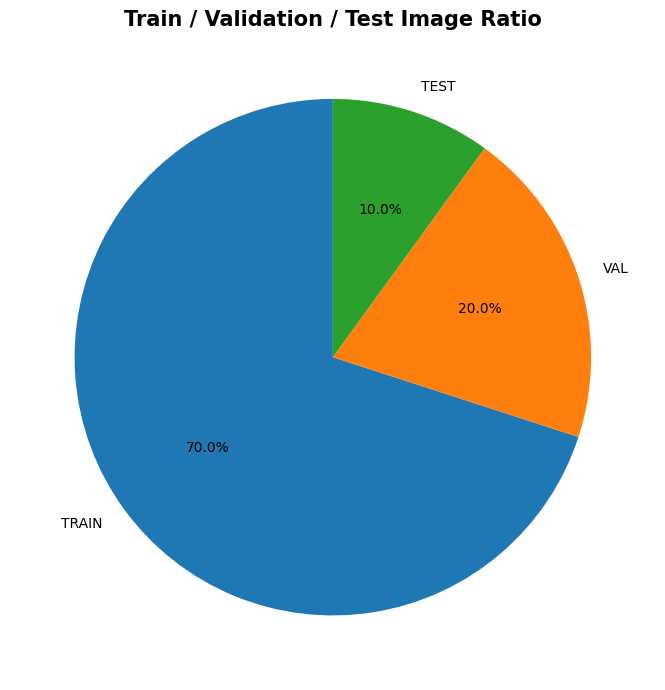

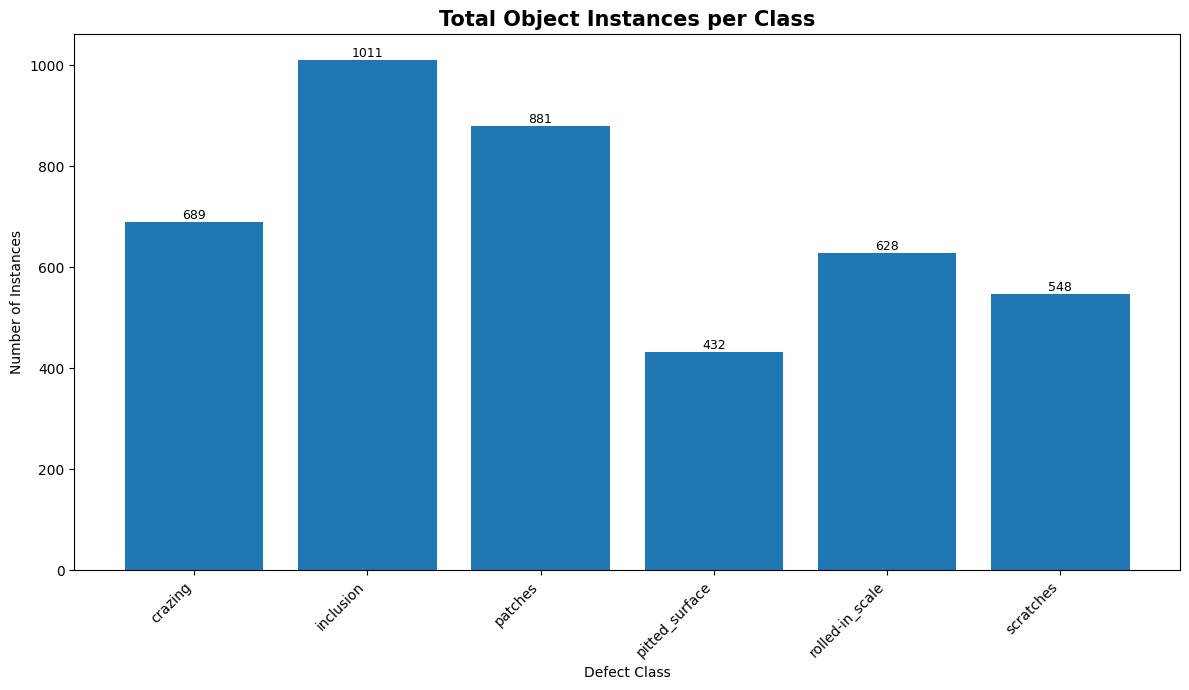

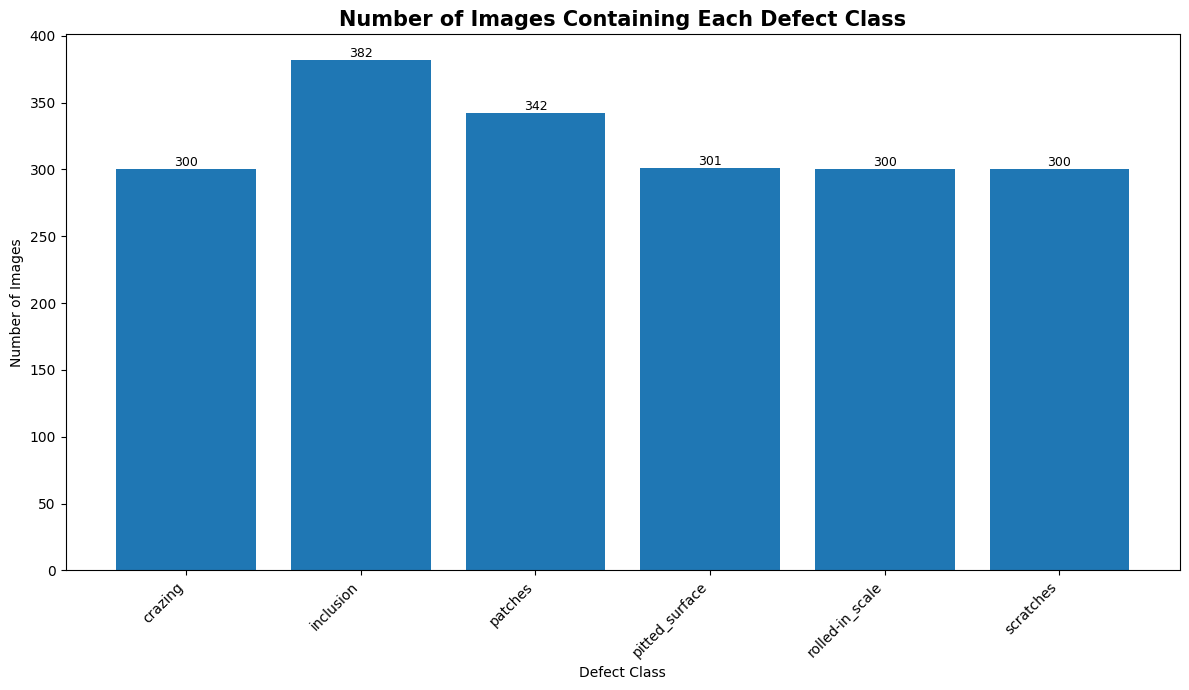

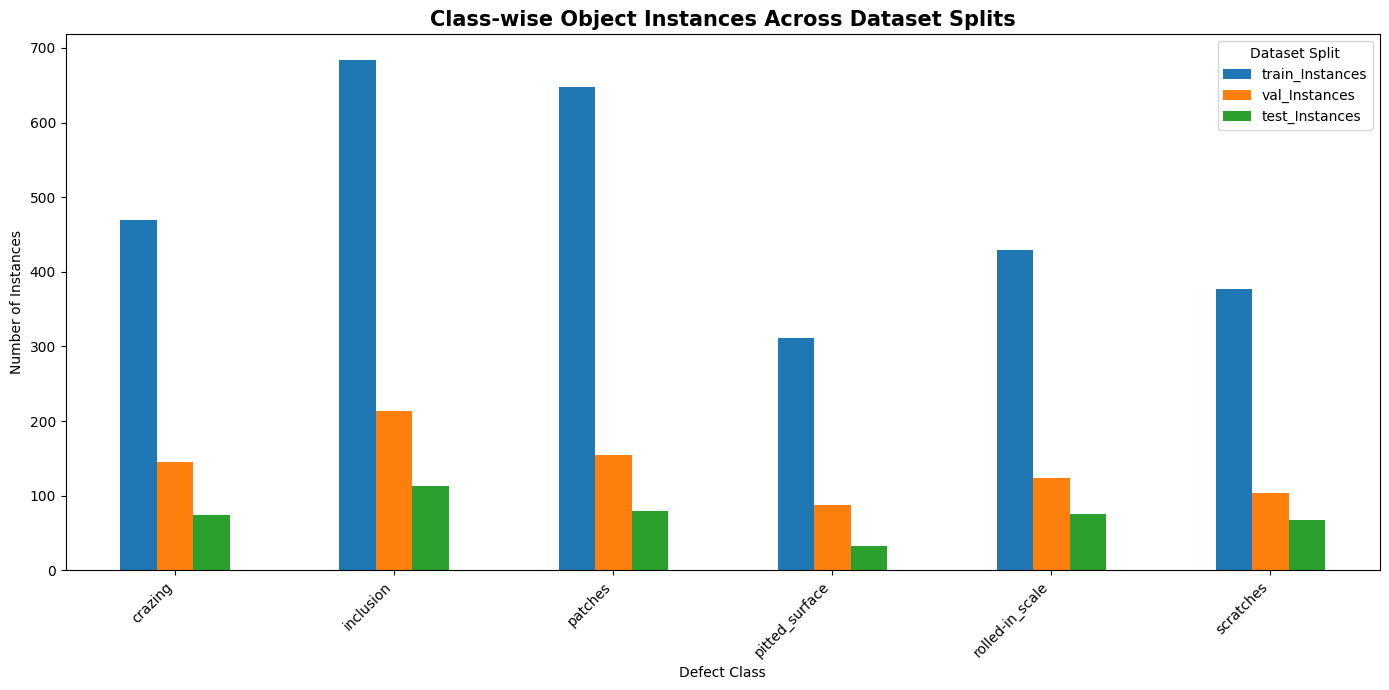

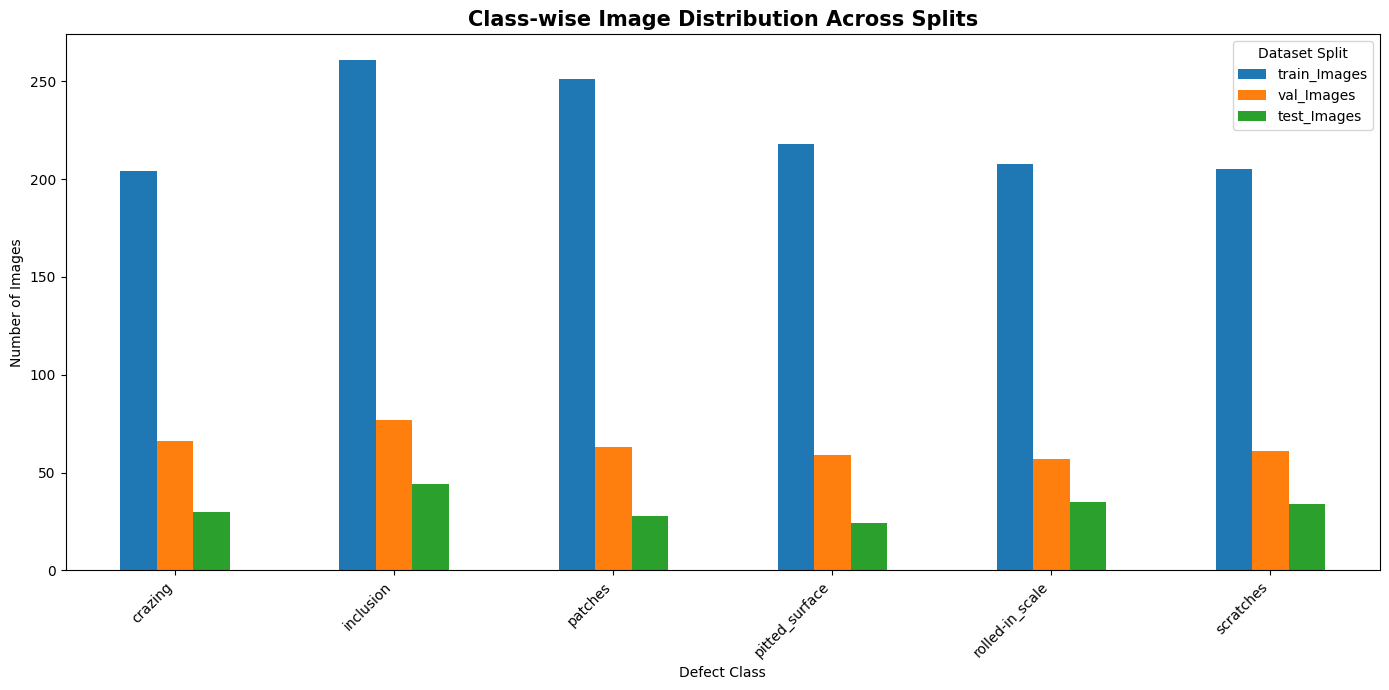

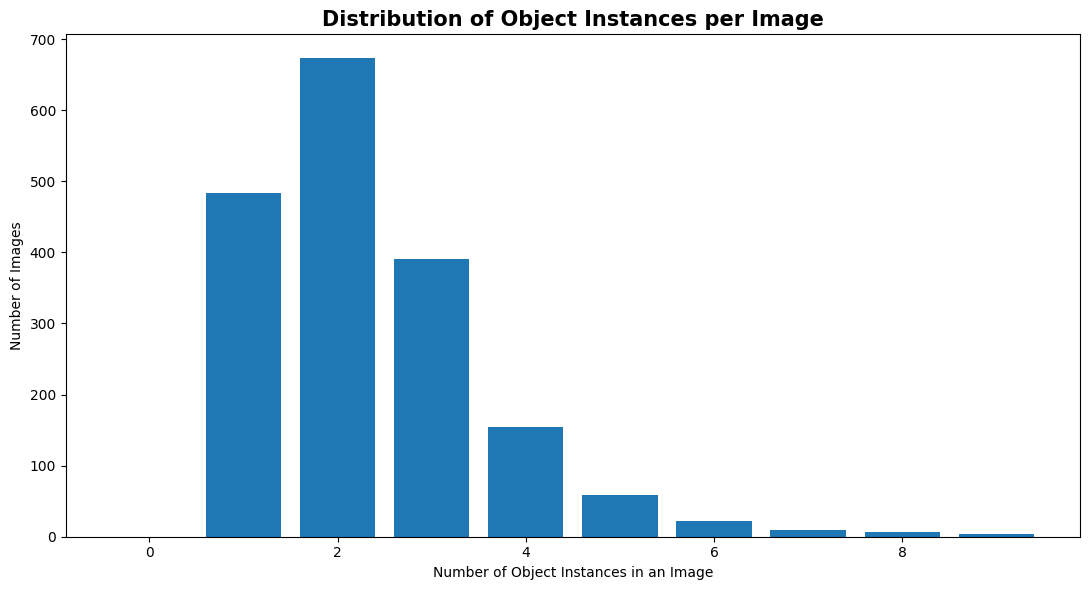

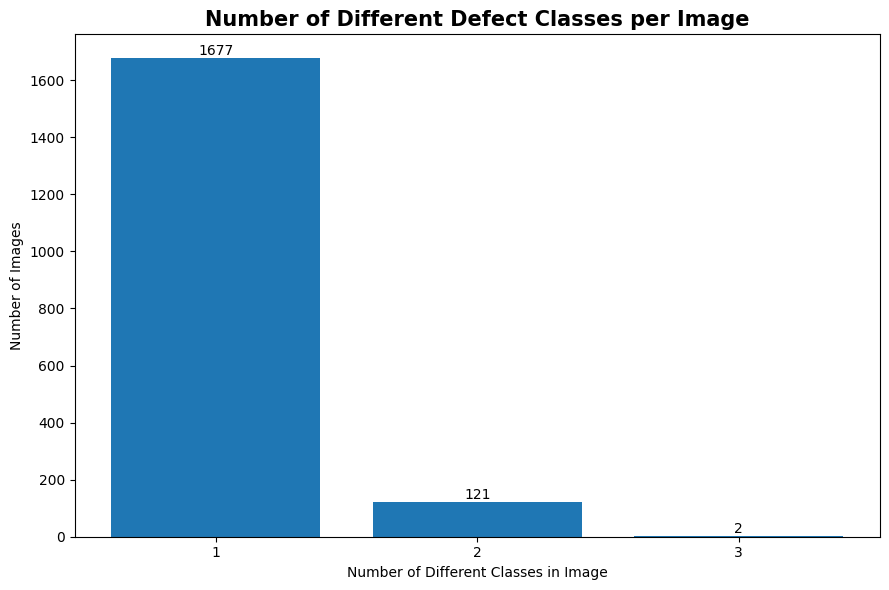

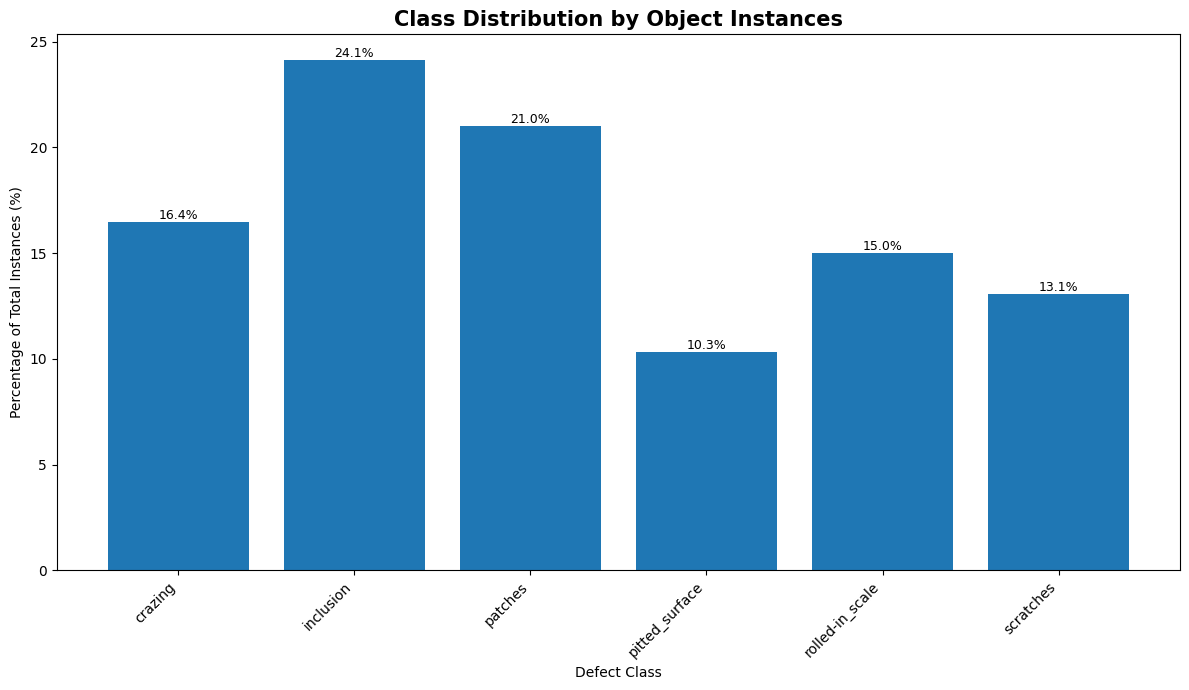

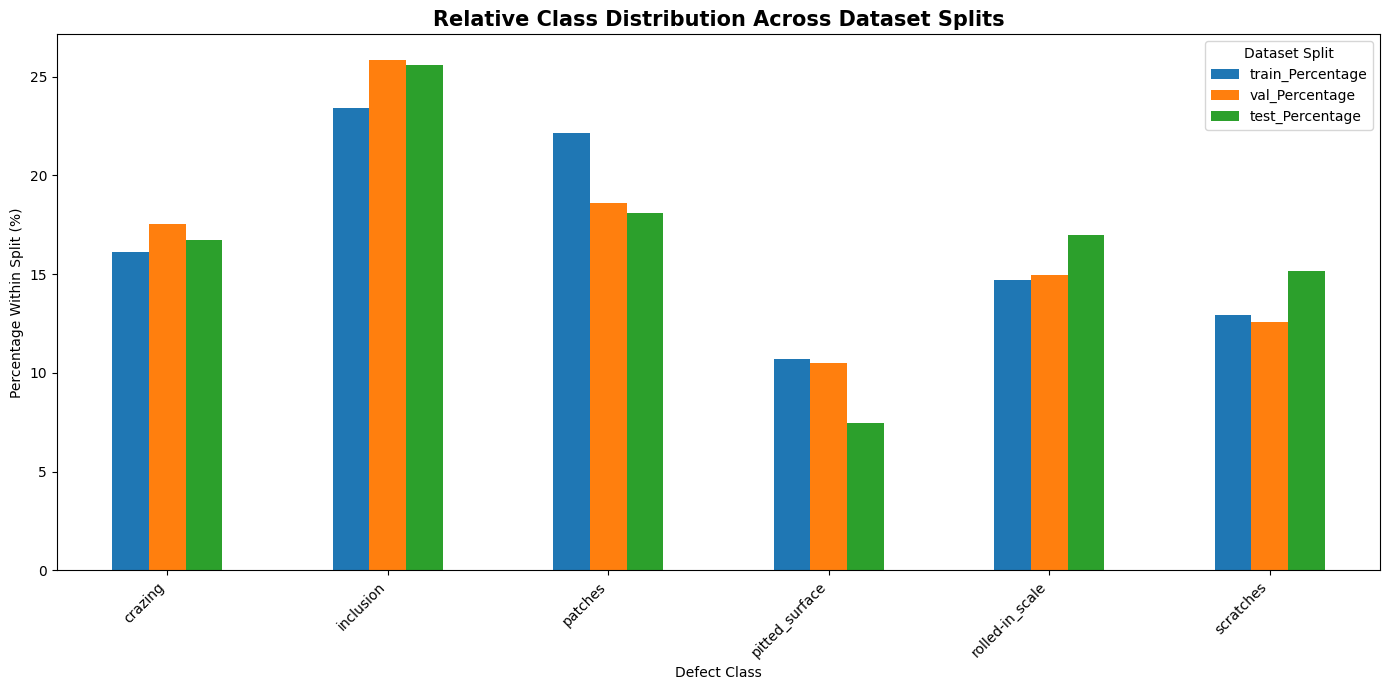

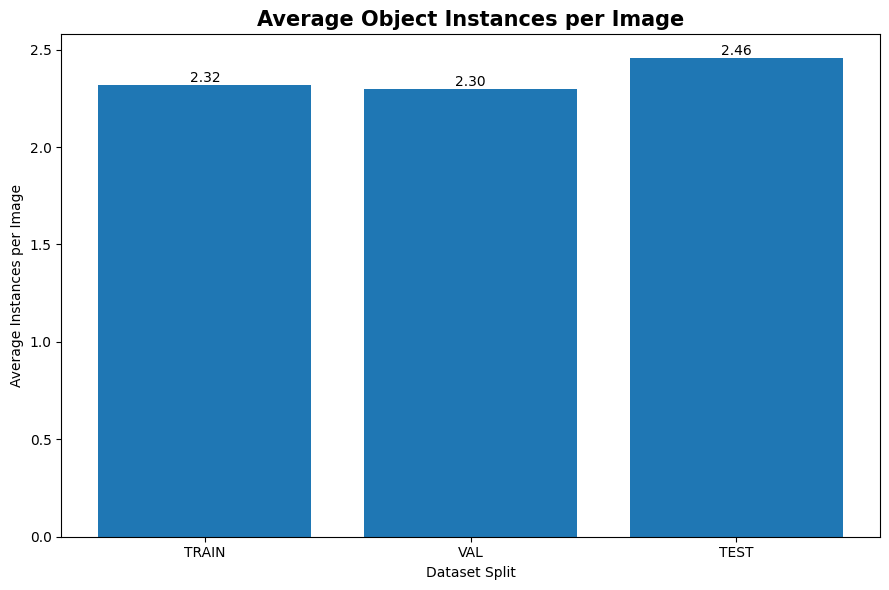

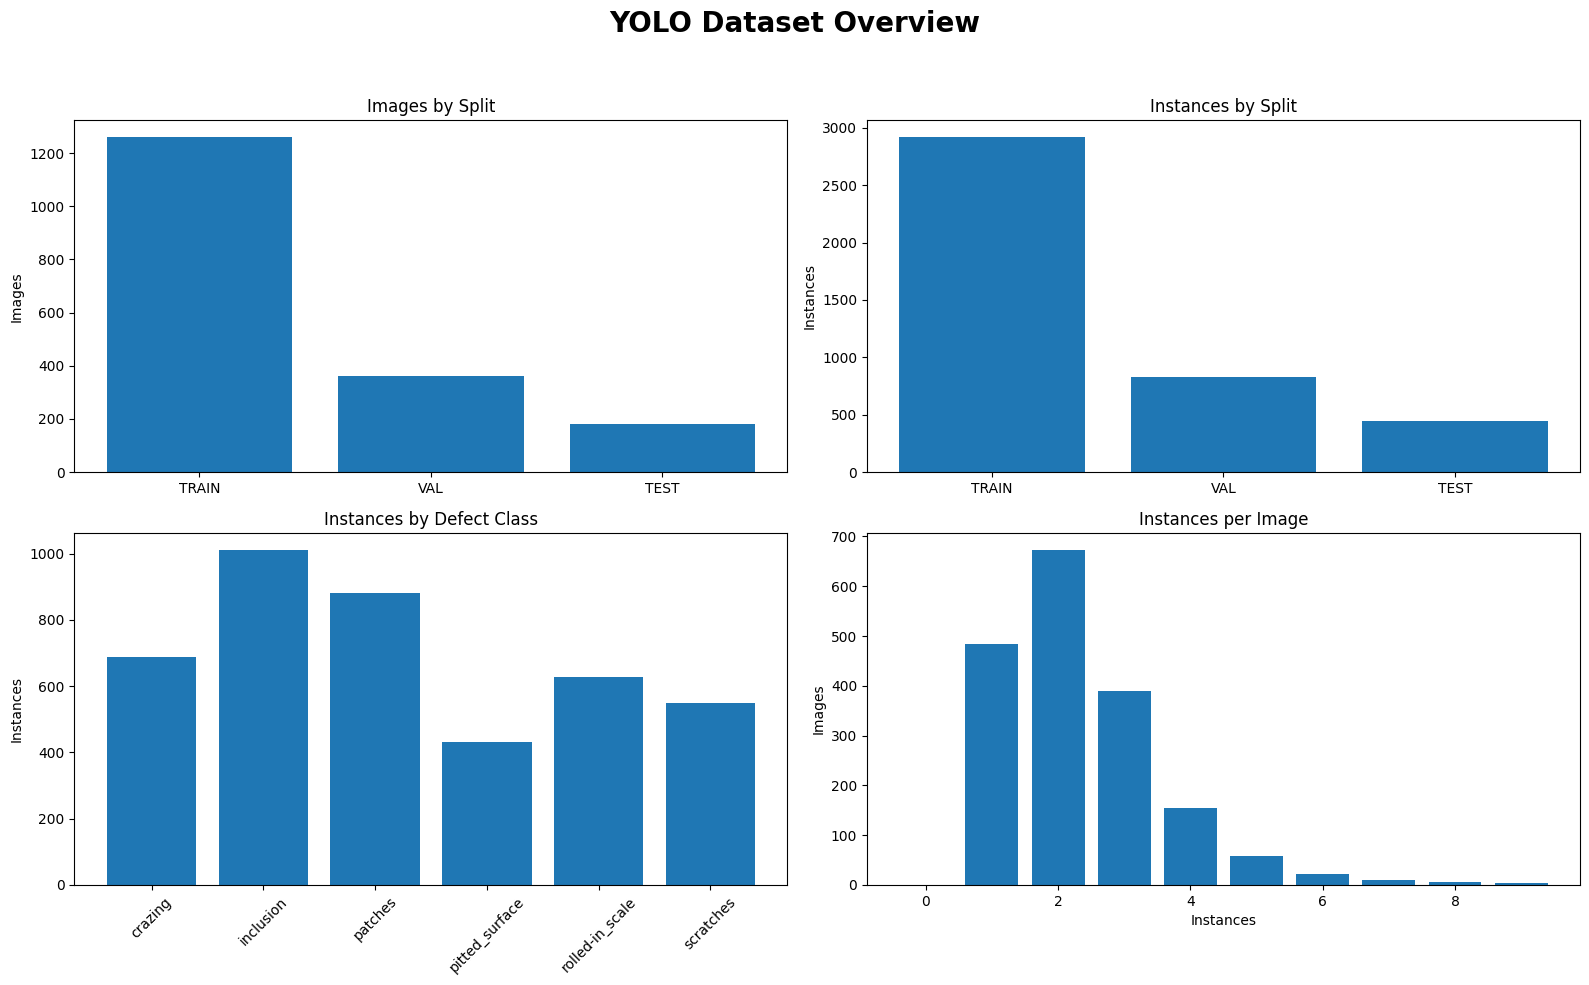


AUTOMATIC DATASET INTERPRETATION
Total images              : 1800
Total object instances    : 4189
Number of classes         : 6
Average objects/image     : 2.33
Most represented class    : inclusion
Instances                 : 1011
Least represented class   : pitted_surface
Instances                 : 432
Maximum/Minimum ratio     : 2.34:1

Interpretation:
• The class-instance distribution can be used to assess class imbalance.
• The train/validation/test charts can be used to verify the 8:1:1 partition.
• The instances-per-image histogram shows whether images contain mostly single or multiple defects.
• The class-wise split charts show whether class representation is consistent across train, validation, and test sets.
Visualization completed successfully.


In [1]:
# ================================================================
# YOLO DATASET VISUALIZATION & ANALYSIS
# Single-cell Jupyter / Google Colab script
# ================================================================

from pathlib import Path
from collections import Counter
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# 1. CHANGE ONLY THIS PATH
# ================================================================

DATASET_ROOT = Path(r"D:\MY Projects\Steel Defect Detection\data\processed_v2")

# Example:
# DATASET_ROOT = Path(r"D:\Datasets\GC10-DET")


# ================================================================
# 2. FIND data.yaml
# ================================================================

yaml_files = (
    list(DATASET_ROOT.glob("*.yaml")) +
    list(DATASET_ROOT.glob("*.yml"))
)

if not yaml_files:
    raise FileNotFoundError(
        "No data.yaml / data.yml found in DATASET_ROOT."
    )

YAML_PATH = yaml_files[0]

with open(YAML_PATH, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)


# ================================================================
# 3. READ CLASS NAMES
# ================================================================

names = data.get("names", {})

if isinstance(names, list):
    CLASS_NAMES = {
        i: str(name)
        for i, name in enumerate(names)
    }
else:
    CLASS_NAMES = {
        int(k): str(v)
        for k, v in names.items()
    }

NUM_CLASSES = len(CLASS_NAMES)


# ================================================================
# 4. FIND DATASET DIRECTORIES
# ================================================================

def find_split(split):

    image_candidates = [
        DATASET_ROOT / "images" / split,
        DATASET_ROOT / split / "images"
    ]

    label_candidates = [
        DATASET_ROOT / "labels" / split,
        DATASET_ROOT / split / "labels"
    ]

    image_dir = next(
        (p for p in image_candidates if p.exists()),
        None
    )

    label_dir = next(
        (p for p in label_candidates if p.exists()),
        None
    )

    return image_dir, label_dir


IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}


# ================================================================
# 5. ANALYZE EACH SPLIT
# ================================================================

def analyze_split(split):

    image_dir, label_dir = find_split(split)

    if image_dir is None:
        return None

    images = [
        p for p in image_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_instances = Counter()
    class_images = Counter()

    instances_per_image = []
    classes_per_image = []

    for image_path in images:

        if label_dir is None:
            continue

        label_path = label_dir / (image_path.stem + ".txt")

        image_classes = []
        instance_count = 0

        if label_path.exists():

            with open(
                label_path,
                "r",
                encoding="utf-8"
            ) as f:

                lines = [
                    line.strip()
                    for line in f
                    if line.strip()
                ]

            for line in lines:

                parts = line.split()

                if len(parts) < 5:
                    continue

                try:
                    class_id = int(float(parts[0]))

                    if class_id not in CLASS_NAMES:
                        continue

                    class_instances[class_id] += 1

                    image_classes.append(class_id)

                    instance_count += 1

                except:
                    continue

        instances_per_image.append(
            instance_count
        )

        unique_classes = set(image_classes)

        classes_per_image.append(
            len(unique_classes)
        )

        for class_id in unique_classes:
            class_images[class_id] += 1

    return {
        "images": len(images),
        "instances": sum(class_instances.values()),
        "class_instances": class_instances,
        "class_images": class_images,
        "instances_per_image": instances_per_image,
        "classes_per_image": classes_per_image
    }


# ================================================================
# 6. RUN ANALYSIS
# ================================================================

results = {}

for split in ["train", "val", "test"]:

    result = analyze_split(split)

    if result is not None:
        results[split] = result


if not results:
    raise RuntimeError(
        "No train/val/test directories found."
    )


# ================================================================
# 7. COMBINE DATA
# ================================================================

total_images = sum(
    r["images"]
    for r in results.values()
)

total_instances = sum(
    r["instances"]
    for r in results.values()
)


# ================================================================
# 8. DATAFRAME: SPLIT INFORMATION
# ================================================================

split_rows = []

for split, r in results.items():

    split_rows.append({
        "Split": split.upper(),
        "Images": r["images"],
        "Instances": r["instances"],
        "Image_Percentage":
            r["images"] / total_images * 100,
        "Instance_Percentage":
            r["instances"] / total_instances * 100
    })

split_df = pd.DataFrame(split_rows)


# ================================================================
# 9. DATAFRAME: CLASS INFORMATION
# ================================================================

class_rows = []

for cid in sorted(CLASS_NAMES):

    total_class_instances = sum(
        r["class_instances"][cid]
        for r in results.values()
    )

    total_class_images = sum(
        r["class_images"][cid]
        for r in results.values()
    )

    row = {
        "Class_ID": cid,
        "Class": CLASS_NAMES[cid],
        "Instances": total_class_instances,
        "Images": total_class_images
    }

    for split, r in results.items():

        row[f"{split}_Instances"] = \
            r["class_instances"][cid]

        row[f"{split}_Images"] = \
            r["class_images"][cid]

    class_rows.append(row)

class_df = pd.DataFrame(class_rows)


# ================================================================
# 10. PRINT SUMMARY
# ================================================================

print("\n" + "=" * 75)
print("              YOLO DATASET VISUAL ANALYSIS")
print("=" * 75)

print(f"\nDataset : {DATASET_ROOT}")
print(f"Classes : {NUM_CLASSES}")
print(f"Images  : {total_images}")
print(f"Objects : {total_instances}")

print(
    f"Average objects/image : "
    f"{total_instances / total_images:.2f}"
)


print("\n" + "-" * 75)
print("SPLIT INFORMATION")
print("-" * 75)

print(
    split_df.round(2).to_string(index=False)
)


print("\n" + "-" * 75)
print("CLASS DISTRIBUTION")
print("-" * 75)

print(
    class_df.round(2).to_string(index=False)
)


# ================================================================
# 11. CHART 1
# TRAIN / VAL / TEST IMAGE DISTRIBUTION
# ================================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    split_df["Split"],
    split_df["Images"]
)

plt.title(
    "Dataset Image Distribution by Split",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

for bar, value in zip(
    bars,
    split_df["Images"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()


# ================================================================
# 12. CHART 2
# TRAIN / VAL / TEST INSTANCE DISTRIBUTION
# ================================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    split_df["Split"],
    split_df["Instances"]
)

plt.title(
    "Object Instance Distribution by Split",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Object Instances")

for bar, value in zip(
    bars,
    split_df["Instances"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()


# ================================================================
# 13. CHART 3
# TRAIN / VAL / TEST PERCENTAGE
# ================================================================

plt.figure(figsize=(7, 7))

plt.pie(
    split_df["Images"],
    labels=split_df["Split"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Train / Validation / Test Image Ratio",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ================================================================
# 14. CHART 4
# TOTAL INSTANCES PER CLASS
# ================================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    class_df["Class"],
    class_df["Instances"]
)

plt.title(
    "Total Object Instances per Class",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Instances")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    class_df["Instances"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 15. CHART 5
# IMAGES CONTAINING EACH CLASS
# ================================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    class_df["Class"],
    class_df["Images"]
)

plt.title(
    "Number of Images Containing Each Defect Class",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    class_df["Images"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 16. CHART 6
# CLASS INSTANCES ACROSS TRAIN / VAL / TEST
# ================================================================

plot_df = class_df[
    ["Class"] +
    [
        f"{split}_Instances"
        for split in results
    ]
]

plot_df = plot_df.set_index("Class")

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Class-wise Object Instances Across Dataset Splits",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Instances")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Dataset Split"
)

plt.tight_layout()
plt.show()


# ================================================================
# 17. CHART 7
# CLASS IMAGES ACROSS TRAIN / VAL / TEST
# ================================================================

plot_df = class_df[
    ["Class"] +
    [
        f"{split}_Images"
        for split in results
    ]
]

plot_df = plot_df.set_index("Class")

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Class-wise Image Distribution Across Splits",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Dataset Split"
)

plt.tight_layout()
plt.show()


# ================================================================
# 18. CHART 8
# INSTANCE DISTRIBUTION PER IMAGE
# ================================================================

all_instances_per_image = []

for r in results.values():

    all_instances_per_image.extend(
        r["instances_per_image"]
    )

plt.figure(figsize=(11, 6))

plt.hist(
    all_instances_per_image,
    bins=range(
        0,
        max(all_instances_per_image) + 2
    ),
    align="left",
    rwidth=0.8
)

plt.title(
    "Distribution of Object Instances per Image",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Number of Object Instances in an Image"
)

plt.ylabel(
    "Number of Images"
)

plt.tight_layout()
plt.show()


# ================================================================
# 19. CHART 9
# NUMBER OF CLASSES PER IMAGE
# ================================================================

all_classes_per_image = []

for r in results.values():

    all_classes_per_image.extend(
        r["classes_per_image"]
    )

class_count = Counter(
    all_classes_per_image
)

x = sorted(class_count)
y = [
    class_count[i]
    for i in x
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    [str(i) for i in x],
    y
)

plt.title(
    "Number of Different Defect Classes per Image",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Number of Different Classes in Image"
)

plt.ylabel(
    "Number of Images"
)

for bar, value in zip(bars, y):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 20. CHART 10
# CLASS IMBALANCE
# ================================================================

class_df["Instance_Percentage"] = (
    class_df["Instances"]
    / total_instances
    * 100
)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    class_df["Class"],
    class_df["Instance_Percentage"]
)

plt.title(
    "Class Distribution by Object Instances",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Percentage of Total Instances (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    class_df["Instance_Percentage"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 21. CHART 11
# TRAIN / VAL / TEST CLASS BALANCE
# ================================================================

percentage_df = class_df[
    ["Class"] +
    [
        f"{split}_Instances"
        for split in results
    ]
].copy()

for split in results:

    percentage_df[
        f"{split}_Percentage"
    ] = (
        percentage_df[
            f"{split}_Instances"
        ]
        / results[split]["instances"]
        * 100
    )

percentage_plot = percentage_df[
    ["Class"] +
    [
        f"{split}_Percentage"
        for split in results
    ]
]

percentage_plot = percentage_plot.set_index(
    "Class"
)

percentage_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Relative Class Distribution Across Dataset Splits",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Percentage Within Split (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Dataset Split"
)

plt.tight_layout()
plt.show()


# ================================================================
# 22. CHART 12
# AVERAGE INSTANCES PER IMAGE BY SPLIT
# ================================================================

average_instances = []

for split, r in results.items():

    avg = (
        r["instances"] / r["images"]
        if r["images"] else 0
    )

    average_instances.append({
        "Split": split.upper(),
        "Average": avg
    })

average_df = pd.DataFrame(
    average_instances
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    average_df["Split"],
    average_df["Average"]
)

plt.title(
    "Average Object Instances per Image",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dataset Split")
plt.ylabel("Average Instances per Image")

for bar, value in zip(
    bars,
    average_df["Average"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 23. FINAL DATASET DASHBOARD
# ================================================================

fig = plt.figure(
    figsize=(16, 10)
)

fig.suptitle(
    "YOLO Dataset Overview",
    fontsize=20,
    fontweight="bold"
)

# ------------------------------------------------
# Dashboard 1: images
# ------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

ax1.bar(
    split_df["Split"],
    split_df["Images"]
)

ax1.set_title(
    "Images by Split"
)

ax1.set_ylabel(
    "Images"
)


# ------------------------------------------------
# Dashboard 2: instances
# ------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

ax2.bar(
    split_df["Split"],
    split_df["Instances"]
)

ax2.set_title(
    "Instances by Split"
)

ax2.set_ylabel(
    "Instances"
)


# ------------------------------------------------
# Dashboard 3: class distribution
# ------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

ax3.bar(
    class_df["Class"],
    class_df["Instances"]
)

ax3.set_title(
    "Instances by Defect Class"
)

ax3.set_ylabel(
    "Instances"
)

ax3.tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------
# Dashboard 4: instance/image
# ------------------------------------------------

ax4 = plt.subplot(2, 2, 4)

ax4.hist(
    all_instances_per_image,
    bins=range(
        0,
        max(all_instances_per_image) + 2
    ),
    align="left",
    rwidth=0.8
)

ax4.set_title(
    "Instances per Image"
)

ax4.set_xlabel(
    "Instances"
)

ax4.set_ylabel(
    "Images"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


# ================================================================
# 24. FINAL AUTOMATIC INTERPRETATION
# ================================================================

max_class = class_df.loc[
    class_df["Instances"].idxmax()
]

min_class = class_df.loc[
    class_df["Instances"].idxmin()
]

# Calculate average instances per image
average_instances_total = (
    total_instances / total_images
    if total_images > 0
    else 0
)

# Calculate imbalance ratio
if min_class["Instances"] > 0:
    imbalance_ratio = (
        max_class["Instances"]
        / min_class["Instances"]
    )
else:
    imbalance_ratio = float("inf")


print("\n" + "=" * 75)
print("AUTOMATIC DATASET INTERPRETATION")
print("=" * 75)

print(f"Total images              : {total_images}")
print(f"Total object instances    : {total_instances}")
print(f"Number of classes         : {NUM_CLASSES}")

print(
    f"Average objects/image     : "
    f"{average_instances_total:.2f}"
)

print(
    f"Most represented class    : "
    f"{max_class['Class']}"
)

print(
    f"Instances                 : "
    f"{int(max_class['Instances'])}"
)

print(
    f"Least represented class   : "
    f"{min_class['Class']}"
)

print(
    f"Instances                 : "
    f"{int(min_class['Instances'])}"
)

if imbalance_ratio != float("inf"):

    print(
        f"Maximum/Minimum ratio     : "
        f"{imbalance_ratio:.2f}:1"
    )

else:

    print(
        "Maximum/Minimum ratio     : Undefined "
        "(minimum class has zero instances)"
    )

print("\nInterpretation:")
print(
    "• The class-instance distribution can be used "
    "to assess class imbalance."
)

print(
    "• The train/validation/test charts can be used "
    "to verify the 8:1:1 partition."
)

print(
    "• The instances-per-image histogram shows whether "
    "images contain mostly single or multiple defects."
)

print(
    "• The class-wise split charts show whether class "
    "representation is consistent across train, validation, "
    "and test sets."
)

print("=" * 75)
print("Visualization completed successfully.")
print("=" * 75)